# Logistic Regression — Aimon V2

**Data:** `data/aimon-data/` — V2 pipeline (11 engineered + selected features, StandardScaler applied)  
**Split:** 70 / 15 / 15 (4,773 train / 1,023 val / 1,023 test)  
**Class balance:** 3.23% bankrupt — handled via `class_weight='balanced'`  
**Primary metrics:** Recall and PR-AUC (false negatives are costly)

V2 uses aggressive feature selection (corr pruning → low-var filter → target-corr filter) leaving only the most bankruptcy-relevant features. Fewer features = more interpretable coefficients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    confusion_matrix, classification_report,
    precision_recall_curve
)

DATA_DIR = Path('../data/aimon-data')
RANDOM_STATE = 42

## 1. Load Data

In [2]:
X_train = pd.read_csv(DATA_DIR / 'X_train_v2.csv')
X_val   = pd.read_csv(DATA_DIR / 'X_val_v2.csv')
X_test  = pd.read_csv(DATA_DIR / 'X_test_v2.csv')

y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze()
y_val   = pd.read_csv(DATA_DIR / 'y_val.csv').squeeze()
y_test  = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape} | bankrupt={y_train.mean()*100:.2f}%')
print(f'Val:   {X_val.shape}   | bankrupt={y_val.mean()*100:.2f}%')
print(f'Test:  {X_test.shape}  | bankrupt={y_test.mean()*100:.2f}%')
print(f'\nSelected features ({X_train.shape[1]}):')
for f in X_train.columns:
    print(f'  {f}')

Train: (4773, 11) | bankrupt=3.23%
Val:   (1023, 11)   | bankrupt=3.23%
Test:  (1023, 11)  | bankrupt=3.23%

Selected features (11):
  Operating Expense Rate
  Research and development expense rate
  Tax rate (A)
  Quick Assets/Total Assets
  Current Assets/Total Assets
  Inventory/Current Liability
  Long-term Liability to Current Assets
  Current Asset Turnover Rate
  Quick Asset Turnover Rate
  Fixed Assets to Assets
  feat_quick_to_current


## 2. Train Logistic Regression

Data is already StandardScaled. Use `class_weight='balanced'` for the 3.23% imbalance.

In [3]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
model.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 3. Threshold Tuning on Validation Set

Best threshold (max F1 on val): 0.8544
  Val F1=0.2745 | Recall=0.2121 | Precision=0.3889


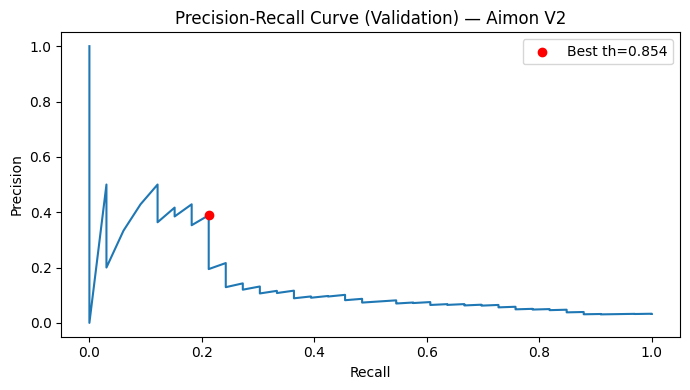

In [4]:
y_val_prob = model.predict_proba(X_val)[:, 1]

precision_arr, recall_arr, thresholds = precision_recall_curve(y_val, y_val_prob)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-8)
best_idx = np.argmax(f1_arr)
best_th  = thresholds[best_idx]

print(f'Best threshold (max F1 on val): {best_th:.4f}')
print(f'  Val F1={f1_arr[best_idx]:.4f} | Recall={recall_arr[best_idx]:.4f} | Precision={precision_arr[best_idx]:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(recall_arr, precision_arr)
plt.scatter(recall_arr[best_idx], precision_arr[best_idx], color='red', zorder=5, label=f'Best th={best_th:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Validation) — Aimon V2')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Evaluate on Test Set

In [5]:
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_th).astype(int)

auc    = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)
f1     = f1_score(y_test, y_test_pred)
rec    = recall_score(y_test, y_test_pred)
prec   = precision_score(y_test, y_test_pred)

print('=== Test Results — Logistic Regression (Aimon V2) ===')
print(f'AUC:       {auc:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}  <- primary metric')
print(f'Recall:    {rec:.4f}  <- primary metric')
print(f'F1:        {f1:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Threshold: {best_th:.4f}')
print()
print('Confusion Matrix (rows=actual, cols=predicted):')
print(confusion_matrix(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred, target_names=['Solvent', 'Bankrupt']))

=== Test Results — Logistic Regression (Aimon V2) ===
AUC:       0.7827
PR-AUC:    0.1233  <- primary metric
Recall:    0.0606  <- primary metric
F1:        0.0851
Precision: 0.1429
Threshold: 0.8544

Confusion Matrix (rows=actual, cols=predicted):
[[978  12]
 [ 31   2]]

              precision    recall  f1-score   support

     Solvent       0.97      0.99      0.98       990
    Bankrupt       0.14      0.06      0.09        33

    accuracy                           0.96      1023
   macro avg       0.56      0.52      0.53      1023
weighted avg       0.94      0.96      0.95      1023



## 5. Coefficients (Feature Importance)

With only 11 features, each coefficient is directly interpretable.

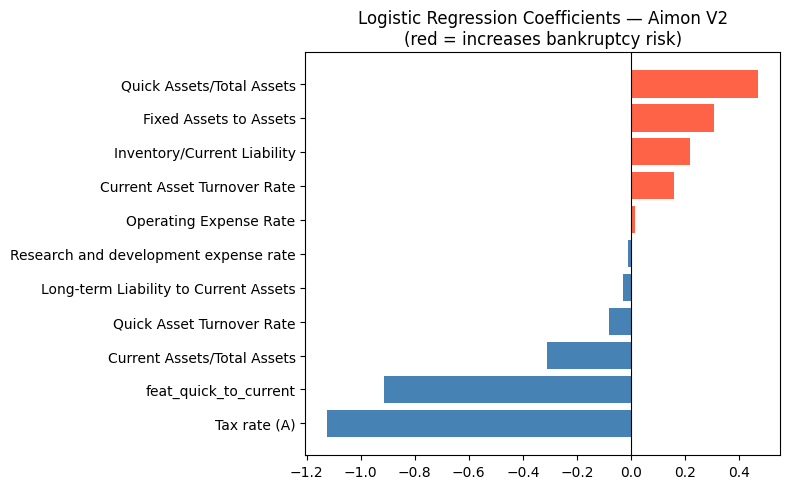


Coefficients (sorted by magnitude):
                              feature  coefficient
                         Tax rate (A)    -1.124631
                feat_quick_to_current    -0.914188
            Quick Assets/Total Assets     0.471515
          Current Assets/Total Assets    -0.310413
               Fixed Assets to Assets     0.307854
          Inventory/Current Liability     0.219334
          Current Asset Turnover Rate     0.157627
            Quick Asset Turnover Rate    -0.080980
Long-term Liability to Current Assets    -0.030562
               Operating Expense Rate     0.016146
Research and development expense rate    -0.011392


In [6]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]

plt.figure(figsize=(8, 5))
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients — Aimon V2\n(red = increases bankruptcy risk)')
plt.tight_layout()
plt.show()

print('\nCoefficients (sorted by magnitude):')
print(coef_df.assign(abs_coef=coef_df['coefficient'].abs()).sort_values('abs_coef', ascending=False)[['feature','coefficient']].to_string(index=False))